In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('/home/noda/Projects/raman-spectroscopy/data/combined_raman_data.csv')

X = df[['Brain', 'Prominence_1', 'Prominence_2', 'Prominence_3', 'Prominence_4', 'Prominence_5', 'Prominence_6']]
y = df['Label']

X = df.drop(columns=['Brain', 'Label', 'Group'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

LinearDiscriminantAnalysis()

In [8]:
coeffs = pd.DataFrame(lda.coef_, columns=X.columns)


In [9]:
print(coeffs)

      Wave_1  Intensity_1  Prominence_1     Wave_2  Intensity_2  Prominence_2  \
0  17.200524     2.640700      2.177457  -7.309557    -4.471556     -2.074219   
1 -42.436888    -3.294681      4.926237  35.836911    11.955819     -6.421739   
2  24.029924    -0.962533    -11.833499 -35.927053    -7.581146     13.769985   

      Wave_3  Intensity_3  Prominence_3    Wave_4  Intensity_4  Prominence_4  \
0  -9.759373     1.576050      0.856426 -0.131033    -0.052668     -1.276879   
1   3.714596     1.042979     -2.055312 -0.018696    -1.263858      0.274390   
2  15.779779    -4.921302      1.113193  0.310910     1.939686      2.370230   

     Wave_5  Intensity_5  Prominence_5    Wave_6  Intensity_6  Prominence_6  
0  0.516421    -2.713210     -1.049145 -0.741057     3.087737      0.404776  
1 -0.334052     0.346743     -3.586640  1.151019    -8.516363      2.113416  
2 -0.636391     5.377771      7.453851 -0.056960     5.611317     -3.929728  


/home/noda/Projects/raman-spectroscopy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(


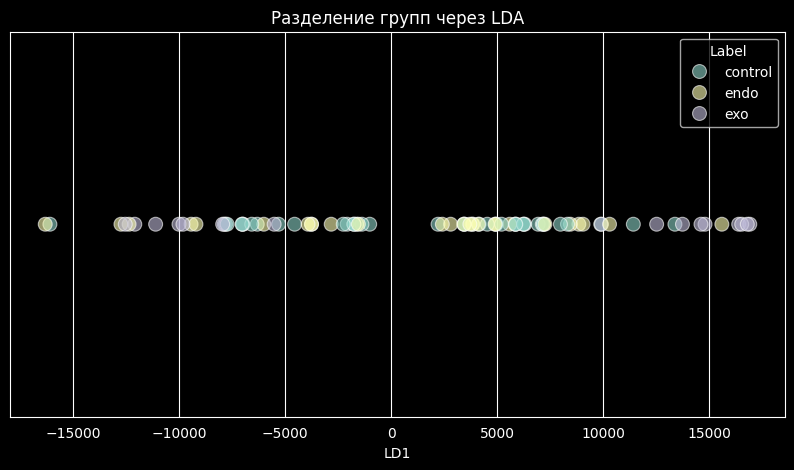

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Получаем результаты LDA
X_lda = lda.transform(X)

# Создаем DataFrame, явно указывая данные
# Используем только первую компоненту (LD1)
plot_df = pd.DataFrame(data=X_lda[:, 0], columns=['LD1'])
plot_df['Label'] = y.values  # .values гарантирует совпадение индексов

# Строим график
plt.figure(figsize=(10, 5))
sns.scatterplot(data=plot_df, x='LD1', y=[0]*len(plot_df), hue='Label', s=100, alpha=0.6)
plt.title('Разделение групп через LDA')
plt.yticks([]) # Убираем ось Y, так как она не информативна
plt.show()


In [11]:
print(len(X))     # Должно быть, например, 83
print(len(y))     # Должно быть столько же — 83



83
83
